<a href="https://colab.research.google.com/github/AnindyaNaura12/Data-Mining/blob/main/Jobsheet_8_DBScan_Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

X = df.copy()

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

In [4]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

In [5]:
from sklearn.metrics import silhouette_score

# KMeans
kmeans_score = silhouette_score(X_scaled, kmeans_labels)

# DBSCAN
if len(set(dbscan_labels)) > 1:
    dbscan_score = silhouette_score(X_scaled, dbscan_labels)
else:
    dbscan_score = -1

print("Silhouette KMeans:", round(kmeans_score, 3))
print("Silhouette DBSCAN:", round(dbscan_score, 3))

Silhouette KMeans: 0.46
Silhouette DBSCAN: 0.522


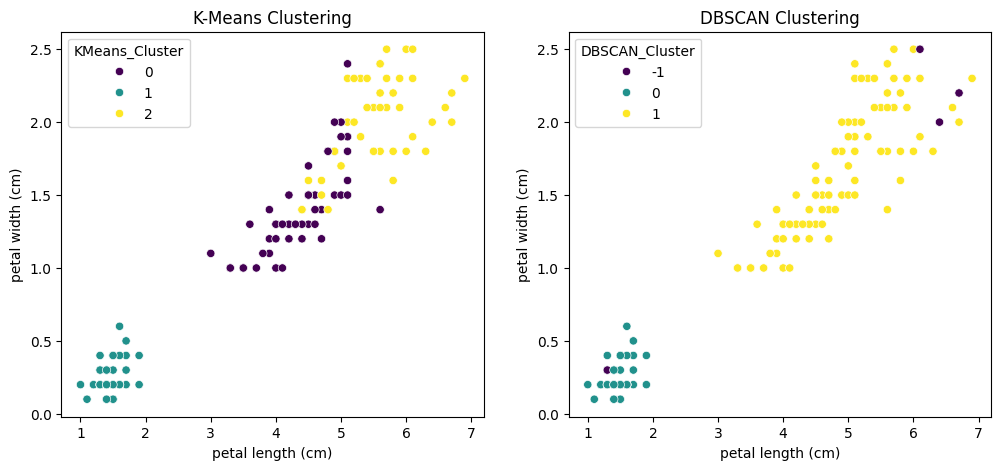

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

# KMeans
plt.subplot(1,2,1)
sns.scatterplot(
    x=df['petal length (cm)'],
    y=df['petal width (cm)'],
    hue=df['KMeans_Cluster'],
    palette='viridis'
)
plt.title("K-Means Clustering")

# DBSCAN
plt.subplot(1,2,2)
sns.scatterplot(
    x=df['petal length (cm)'],
    y=df['petal width (cm)'],
    hue=df['DBSCAN_Cluster'],
    palette='viridis'
)
plt.title("DBSCAN Clustering")

plt.show()